<a href="https://colab.research.google.com/github/mori-mkm/UFSCar/blob/main/Lab1_(regressao)_Mineracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("boston.csv")
df = df.iloc[:,1:]
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,unkw
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,183.351902
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,148.515041
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,383.285055
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,355.104250
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,417.138310


# Nova seção

In [ ]:
# Imports necessários
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score


In [ ]:
# 1. Carregar os dados
# Se estiver usando o sklearn, use datasets.load_boston() (deprecated) ou outro carregamento adequado.
# Você pode carregar de um arquivo CSV, por exemplo.
X = df.loc[:, df.columns != 'medv']  # variáveis explicativas (ex: número de cômodos)
Y = df['medv']  # variável alvo

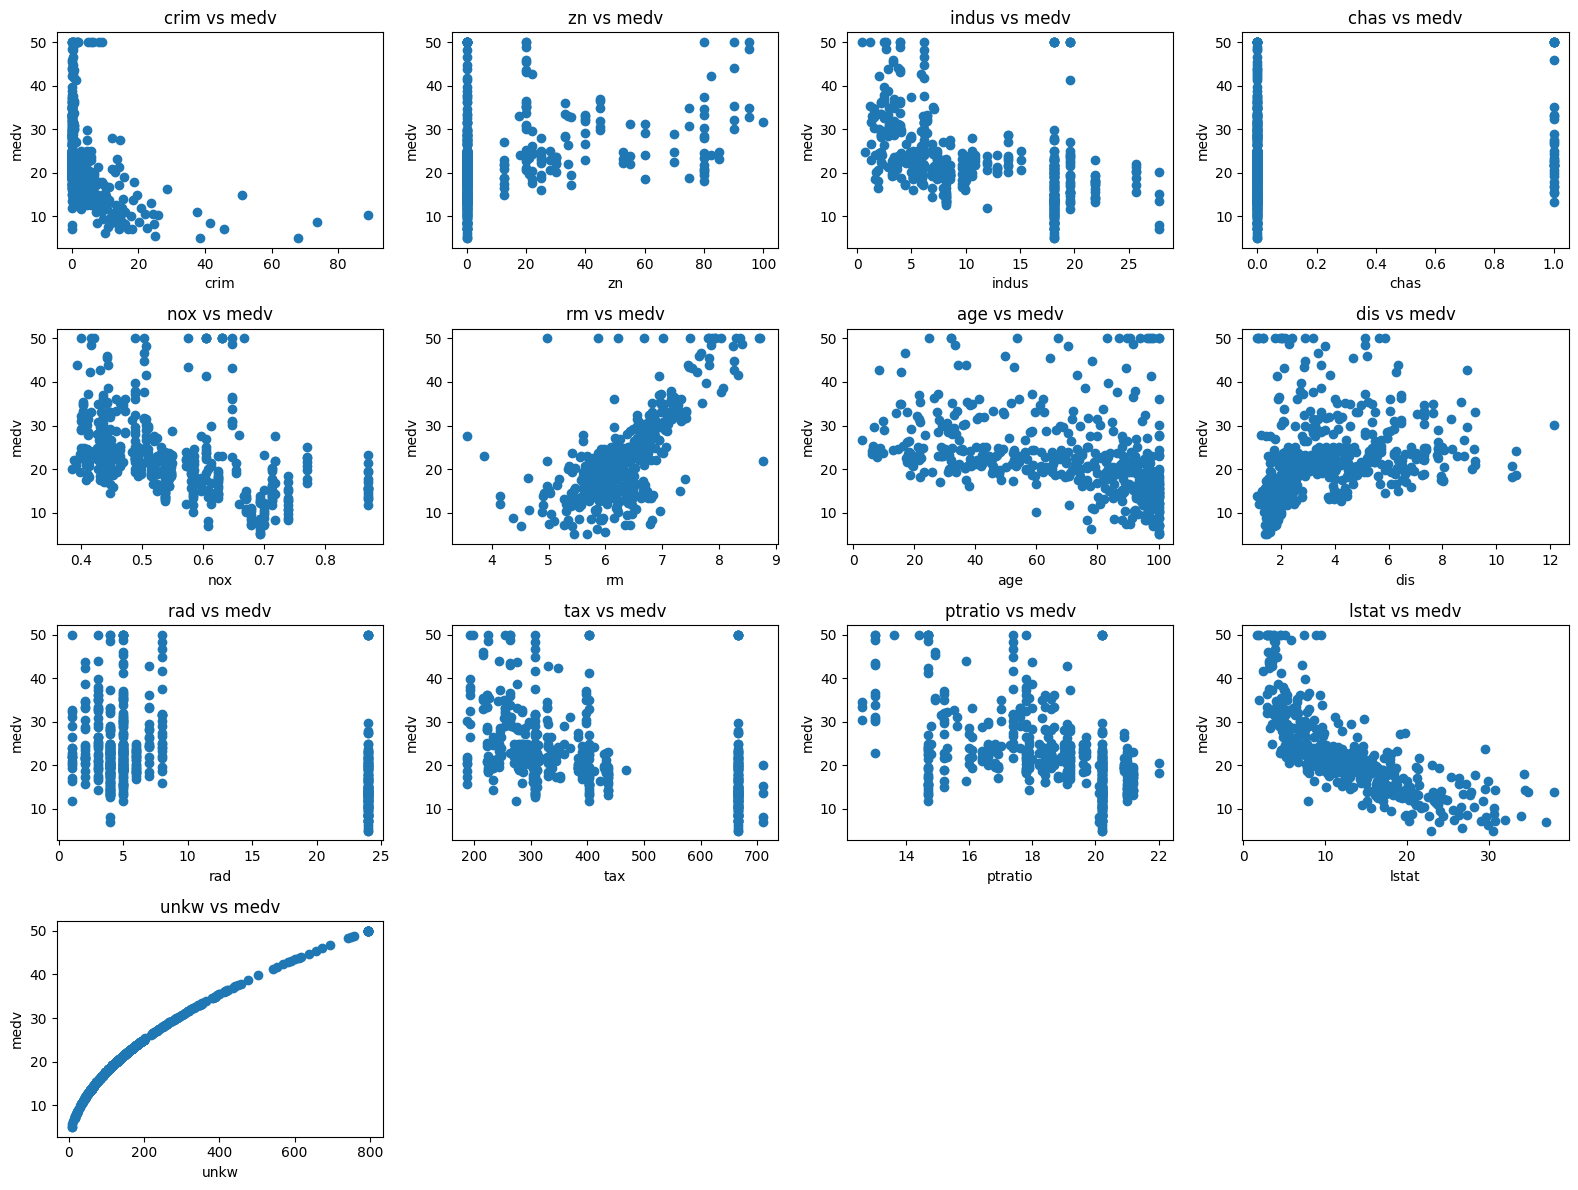

In [ ]:
# 2. Visualizar os dados
# Use scatterplot para ver a relação entre X e Y
variaveis = [col for col in df.columns if col != 'medv']

plt.figure(figsize=(16, 12))

for i, var in enumerate(variaveis):
    plt.subplot(4, 4, i + 1)
    plt.scatter(df[var], df['medv'])
    plt.title(f'{var} vs medv')
    plt.xlabel(var)
    plt.ylabel('medv')

plt.tight_layout()
plt.show()

In [ ]:
X = df[['rm','lstat']]  # variáveis explicativas (ex: número de cômodos)
Y = df['medv']  # variável alvo
# 3. Separar os dados em treino e teste
# Use train_test_split para dividir os dados em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# 4. Ajustar modelo de regressão linear
# Criar e ajustar um modelo LinearRegression com os dados de treino
modelo = LinearRegression()
modelo.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# 5. Fazer previsões e avaliar o modelo
# Usar o modelo para prever os dados de teste e calcular métricas como R² e RMSE
Y_pred = modelo.predict(X_test)
print(r2_score(Y_test, Y_pred))
print(mean_squared_error(Y_test, Y_pred))

0.5739577415025858
31.243290601783627


In [ ]:
# 6. Repetir os passos com regressão polinomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
X_poly_train, X_poly_test, Y_train, Y_test = train_test_split(X_poly, Y, test_size=0.2, random_state=42)
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly_train, Y_train)
Y_pred_poly = modelo_poly.predict(X_poly_test)
print(r2_score(Y_test, Y_pred_poly))
print(mean_squared_error(Y_test, Y_pred_poly))

0.7486318454509404
18.43377773911129


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


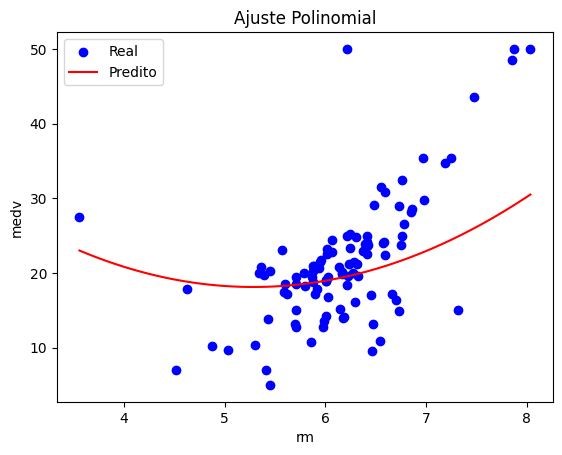

In [ ]:
# 7. Visualizar os resultados da regressão polinomial
# # Gerar curva de predição para comparar com os dados reais
# # Plotar os pontos reais e a curva ajustada pelo modelo

plt.figure()
plt.scatter(X_test['rm'], Y_test, color='blue', label='Real')

x_vals = np.linspace(X_test['rm'].min(), X_test['rm'].max(), 100)
x_aux = np.column_stack((x_vals, np.full_like(x_vals, X_test['lstat'].mean())))
x_aux_poly = poly.transform(x_aux)
y_vals = modelo_poly.predict(x_aux_poly)

plt.plot(x_vals, y_vals, color='red', label='Predito')
plt.xlabel('rm')
plt.ylabel('medv')
plt.title('Ajuste Polinomial')
plt.legend()
plt.show()


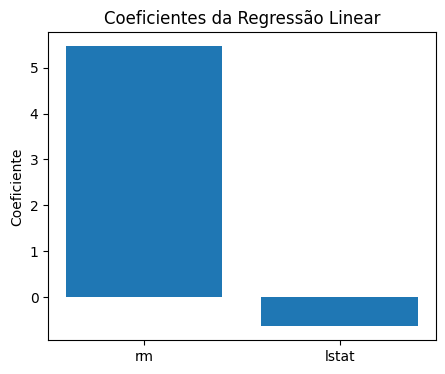

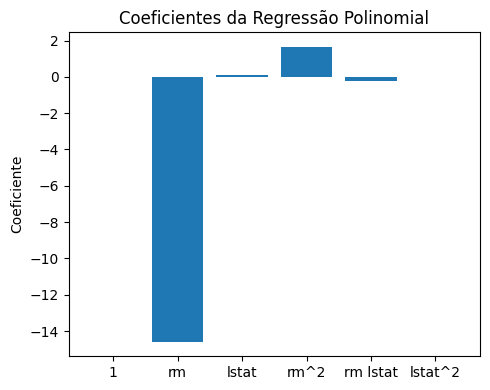

In [ ]:
# 8. Visualizar os coeficientes do modelo
# Após treinar o modelo (modelo.fit), você pode acessar modelo.coef_ para ver os coeficientes
# Ex:
# coeficientes = modelo.coef_
# nomes = X.columns  # ou uma lista manual, como ['rm']
# plt.bar(nomes, coeficientes)
# plt.ylabel("Coeficiente")
# plt.title("Coeficientes da Regressão")


coeficientes = modelo.coef_
nomes = X.columns
plt.figure(figsize=(5, 4))
plt.bar(nomes, coeficientes)
plt.ylabel("Coeficiente")
plt.title("Coeficientes da Regressão Linear")
plt.show()

coeficientes_poly = modelo_poly.coef_
nomes_poly = poly.get_feature_names_out(X.columns)

plt.figure(figsize=(5, 4))
plt.bar(nomes_poly, coeficientes_poly)
plt.ylabel("Coeficiente")
plt.title("Coeficientes da Regressão Polinomial")
plt.tight_layout()
plt.show()
